In [1]:
# Cell 0: Imports and display settings

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("Ready")

ModuleNotFoundError: No module named 'seaborn'

cols: ['Topic', 'Count', 'Name', 'Representation', 'Representative_Docs']


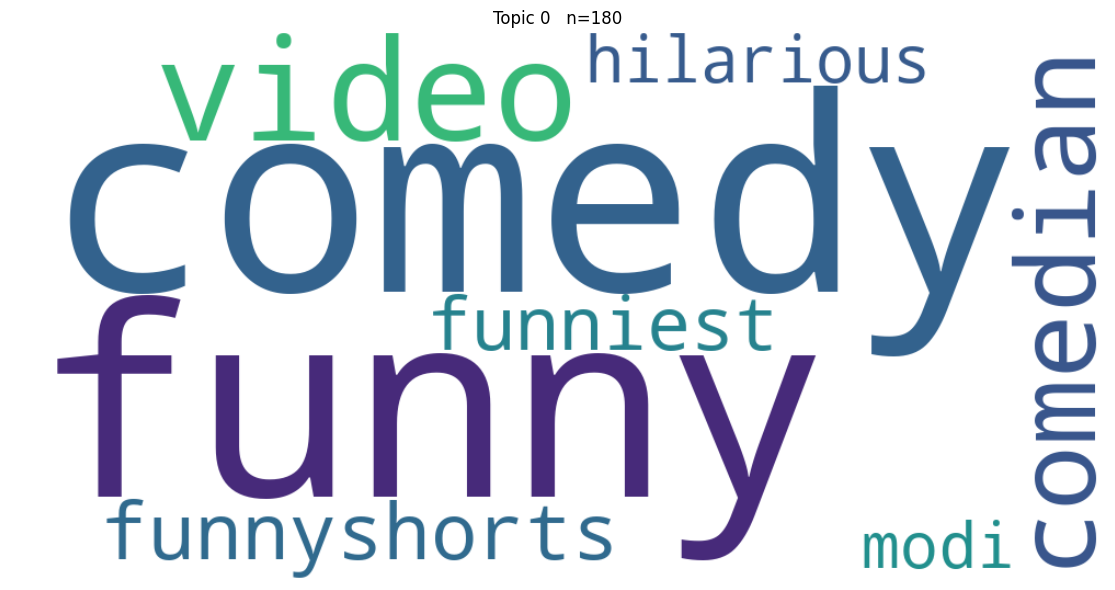

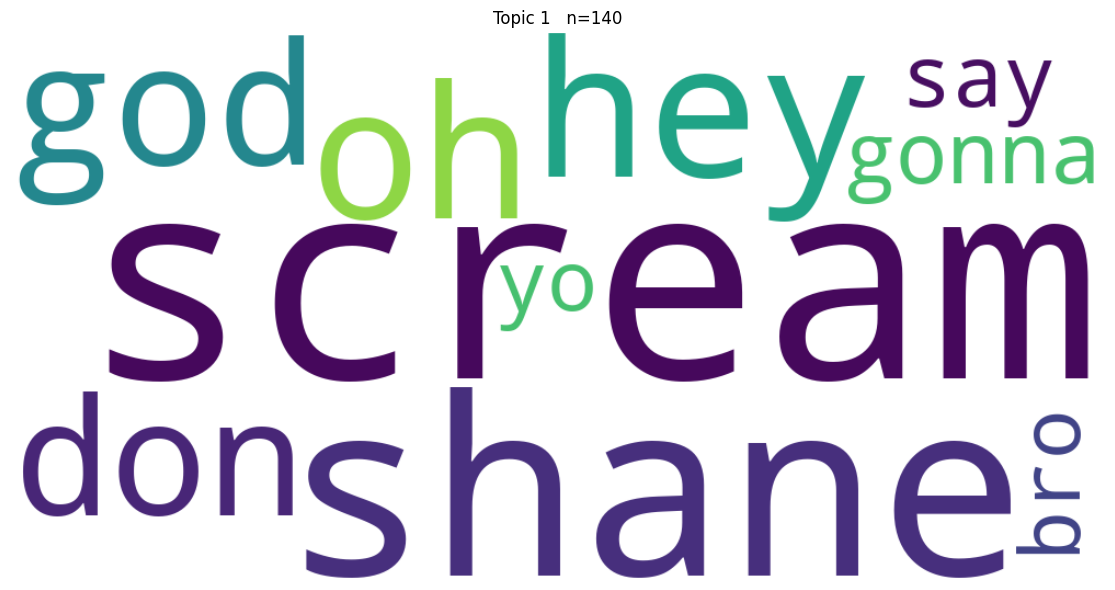

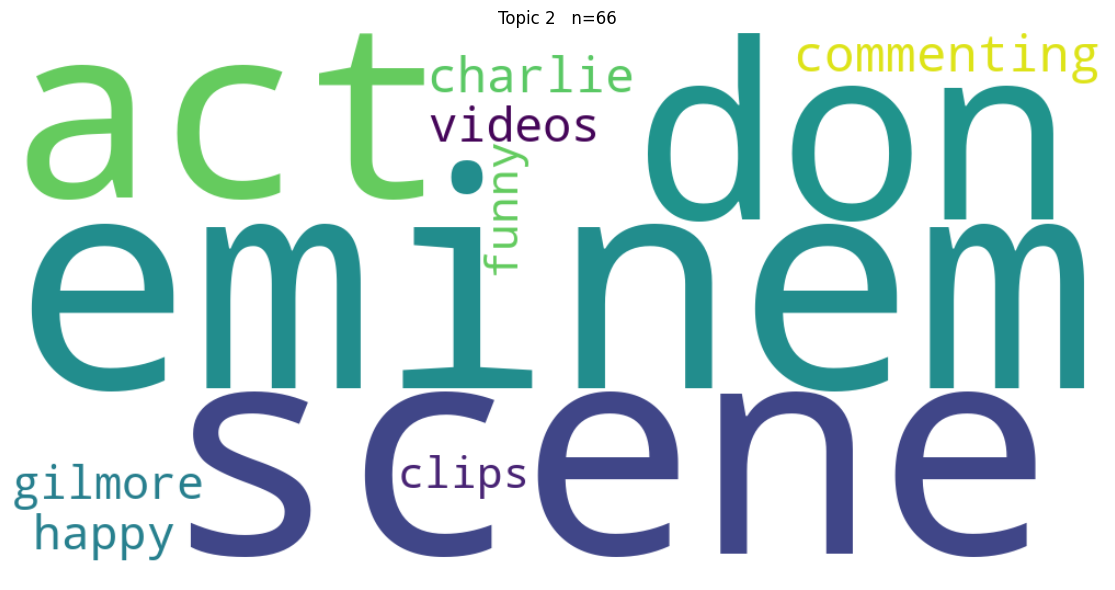

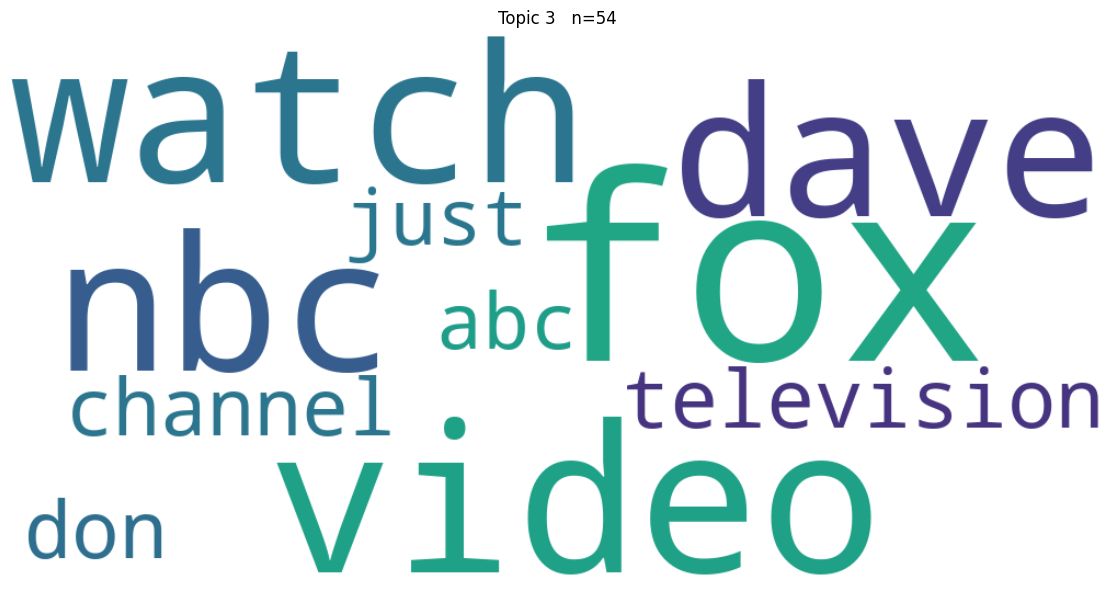

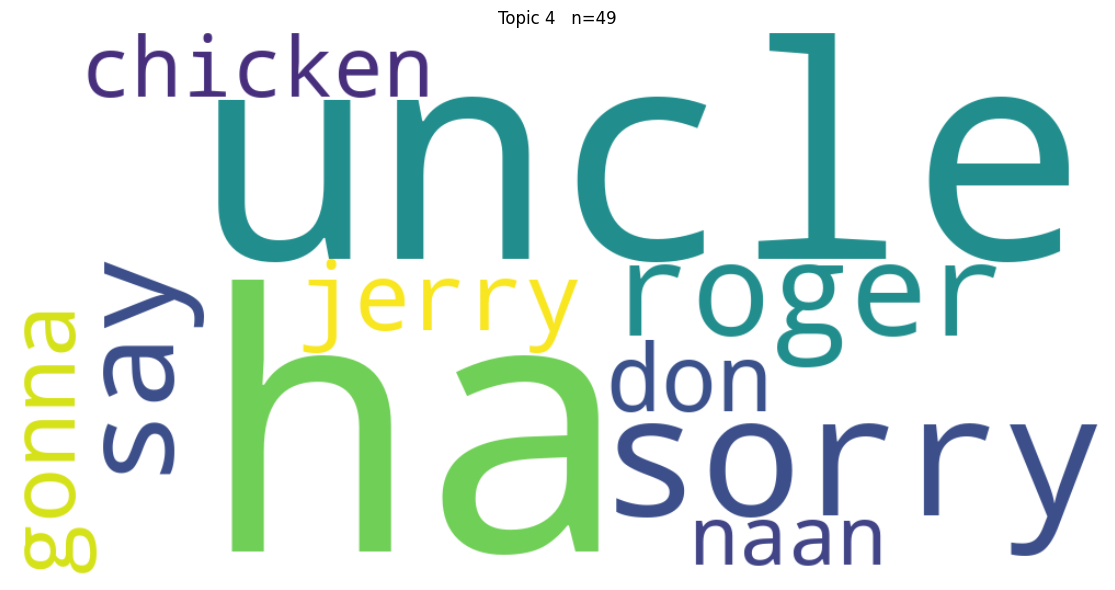

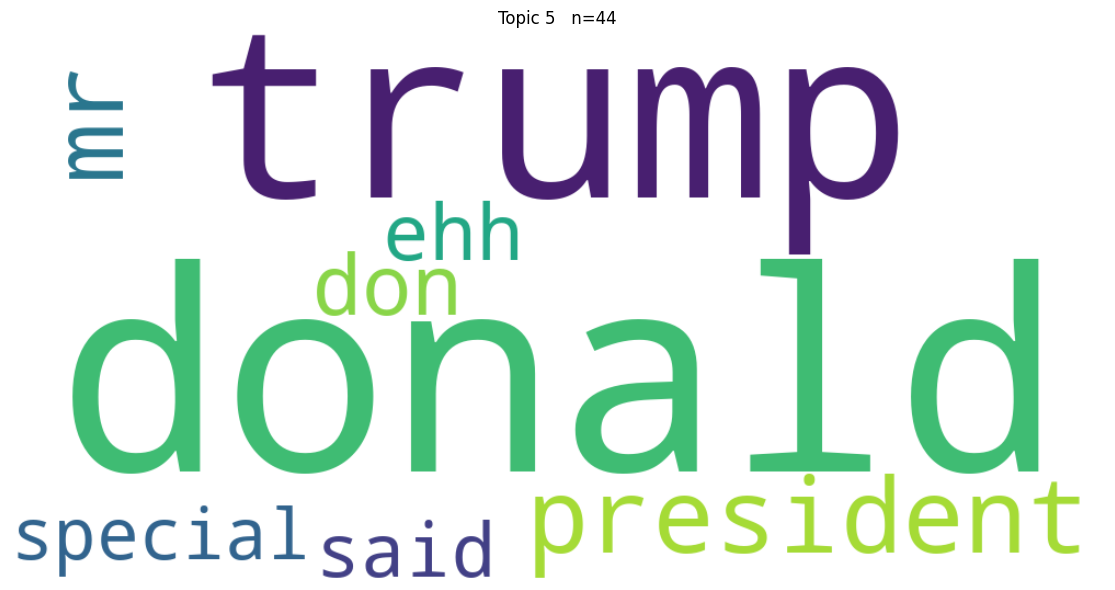

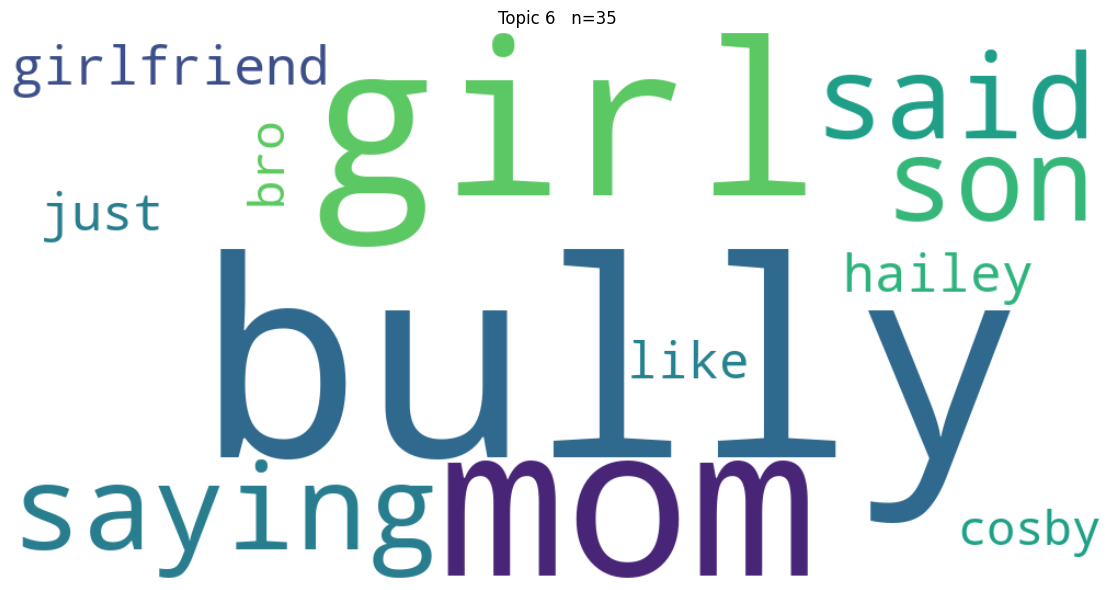

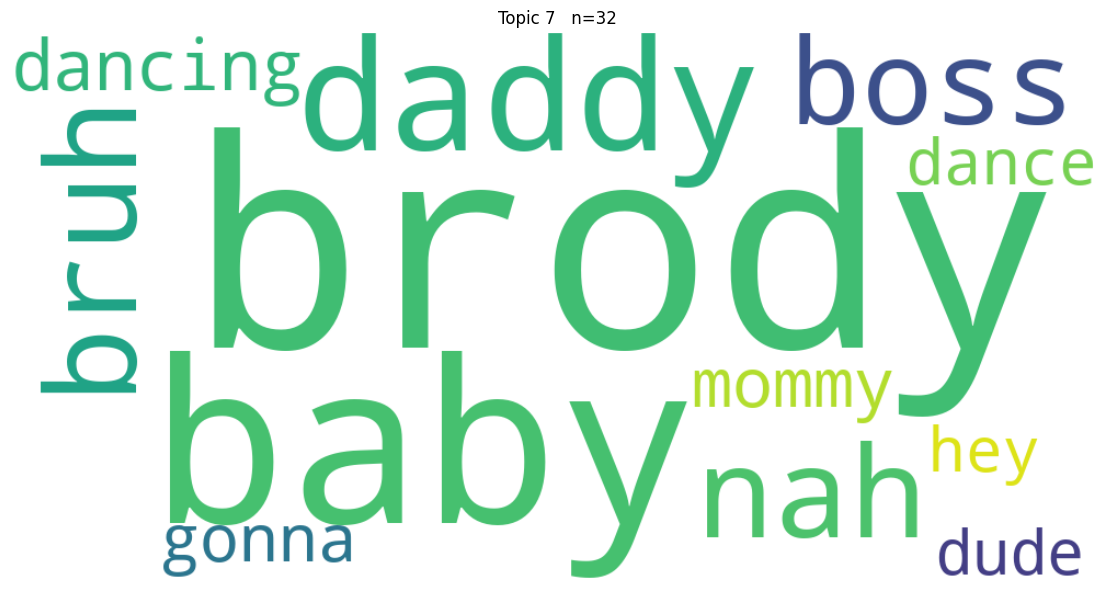

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re

#TOPIC_INFO_PATH = "/home/kiwi-pandas/Documents/humor-harm-api/scripts/topic_analysis/topic_analysis_bertopic_topic_info.csv"
TOPIC_INFO_PATH = r"C:\Users\CS-Admin\Documents\humor-harm-api\scripts\topic_analysis\topic_analysis_bertopic_topic_info.csv"


topic_info = pd.read_csv(TOPIC_INFO_PATH)
print("cols:", list(topic_info.columns))

def extract_words_and_weights(row, top_n=40):
    # Most common BERTopic exports include one of these columns
    text = None
    for c in ["Representation", "Top_n_words", "Words", "Name"]:
        if c in row and pd.notna(row[c]):
            text = str(row[c])
            break

    if text is None:
        return {}

    # Try to parse formats like:
    # "word1, word2, word3"
    # or "['word1', 'word2']"
    # or "word1_word2_word3"
    text = text.replace("_", " ")
    text = re.sub(r"[\[\]\(\)\{\}\'\"]", " ", text)
    parts = re.split(r"[,\s]+", text)
    parts = [p.strip() for p in parts if p.strip()]

    # Make simple frequency weights that decay
    freqs = {}
    for i, w in enumerate(parts[:top_n]):
        # higher weight for earlier words
        freqs[w] = freqs.get(w, 0) + (top_n - i)
    return freqs

# keep real topics only
if "Topic" in topic_info.columns:
    wc_df = topic_info[topic_info["Topic"] != -1].copy()
else:
    wc_df = topic_info.copy()

# pick top N topics by Count if present
TOP_N_TOPICS = 8
if "Count" in wc_df.columns:
    wc_df = wc_df.sort_values("Count", ascending=False).head(TOP_N_TOPICS)
else:
    wc_df = wc_df.head(TOP_N_TOPICS)

for _, row in wc_df.iterrows():
    topic_id = row["Topic"] if "Topic" in wc_df.columns else "NA"
    count = row["Count"] if "Count" in wc_df.columns else None

    freqs = extract_words_and_weights(row, top_n=40)
    if not freqs:
        continue

    wc = WordCloud(width=1000, height=500, background_color="white").generate_from_frequencies(freqs)

    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    title = f"Topic {topic_id}"
    if count is not None:
        title += f"   n={int(count)}"
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [ ]:
# Cell 0: Load files

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#TOPIC_INFO_PATH = "/home/kiwi-pandas/Documents/humor-harm-api/scripts/topic_analysis/topic_analysis_bertopic_topic_info.csv"
TOPIC_INFO_PATH = r"C:\Users\CS-Admin\Documents\humor-harm-api\scripts\topic_analysis\topic_analysis_bertopic_topic_info.csv"


topic_info = pd.read_csv(TOPIC_INFO_PATH)

print("shape:", topic_info.shape)
topic_info.head()

shape: (18, 5)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,349,-1_netflix joke_reality world_don_gonna,"['netflix joke', 'reality world', 'don', 'gonn...",['the way nidal wonder was touching salish mat...
1,0,180,0_comedy video_comedian_funnyshorts_comedy funny,"['comedy video', 'comedian', 'funnyshorts', 'c...",['kattwilliamsinterview standupcomedy comedyco...
2,1,140,1_hey shane_oh god_shane_scream,"['hey shane', 'oh god', 'shane', 'scream', 'do...",['that went way better the second time shorts ...
3,2,66,2_eminem_scene_don_act,"['eminem', 'scene', 'don', 'act', 'commenting'...",['welcome to wealthteachers your hub for your ...
4,3,54,3_video_watch fox_nbc_dave,"['video', 'watch fox', 'nbc', 'dave', 'televis...",['fox news host laura ingraham shreds far left...


In [ ]:
df = topic_info.copy()

df = df[df["Topic"] != -1]

print("topics:", len(df))
df.head()

topics: 17


,Topic,Count,Name,Representation,Representative_Docs
1,0,180,0_comedy video_comedian_funnyshorts_comedy funny,"['comedy video', 'comedian', 'funnyshorts', 'c...",['kattwilliamsinterview standupcomedy comedyco...
2,1,140,1_hey shane_oh god_shane_scream,"['hey shane', 'oh god', 'shane', 'scream', 'do...",['that went way better the second time shorts ...
3,2,66,2_eminem_scene_don_act,"['eminem', 'scene', 'don', 'act', 'commenting'...",['welcome to wealthteachers your hub for your ...
4,3,54,3_video_watch fox_nbc_dave,"['video', 'watch fox', 'nbc', 'dave', 'televis...",['fox news host laura ingraham shreds far left...
5,4,49,4_ha ha_uncle_uncle roger_ha,"['ha ha', 'uncle', 'uncle roger', 'ha', 'say',...",['don t mess with an italian shorts want more ...


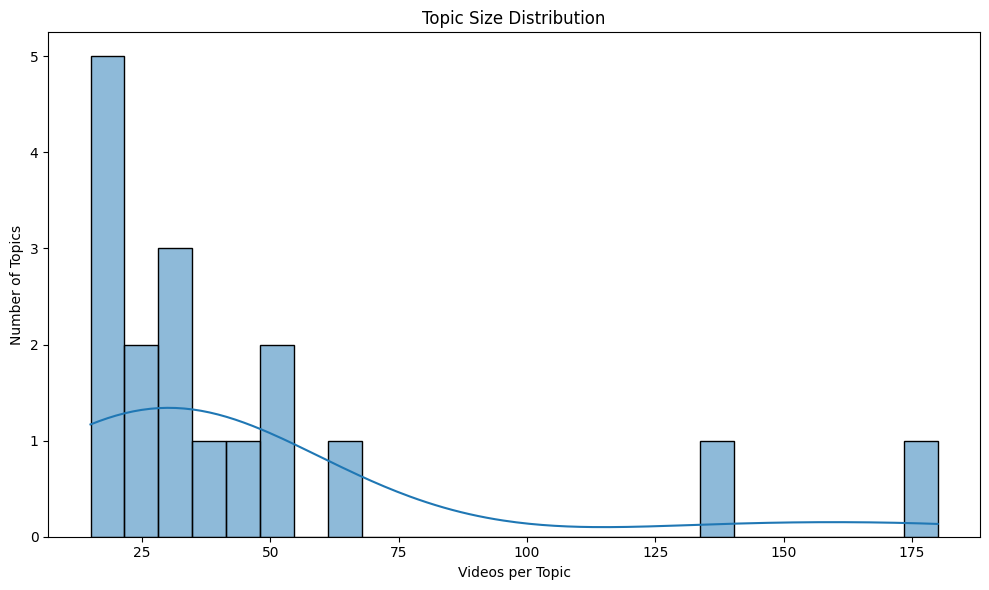

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(df["Count"], bins=25, kde=True)

plt.title("Topic Size Distribution")
plt.xlabel("Videos per Topic")
plt.ylabel("Number of Topics")

plt.tight_layout()
plt.show()

In [ ]:
top_topics = df.sort_values("Count", ascending=False).head(15)

display(top_topics[["Topic","Name","Count"]])

,Topic,Name,Count
1,0,0_comedy video_comedian_funnyshorts_comedy funny,180
2,1,1_hey shane_oh god_shane_scream,140
3,2,2_eminem_scene_don_act,66
4,3,3_video_watch fox_nbc_dave,54
5,4,4_ha ha_uncle_uncle roger_ha,49
6,5,5_don_trump_donald trump_donald,44
7,6,6_bully_girl_mom_saying,35
8,7,7_nah bruh_boss baby_baby brody_brody dancing,32
10,9,9_comedy special_stream comedy_comedy_happy gi...,30
9,8,8_don_funny_jokes_gonna say,30


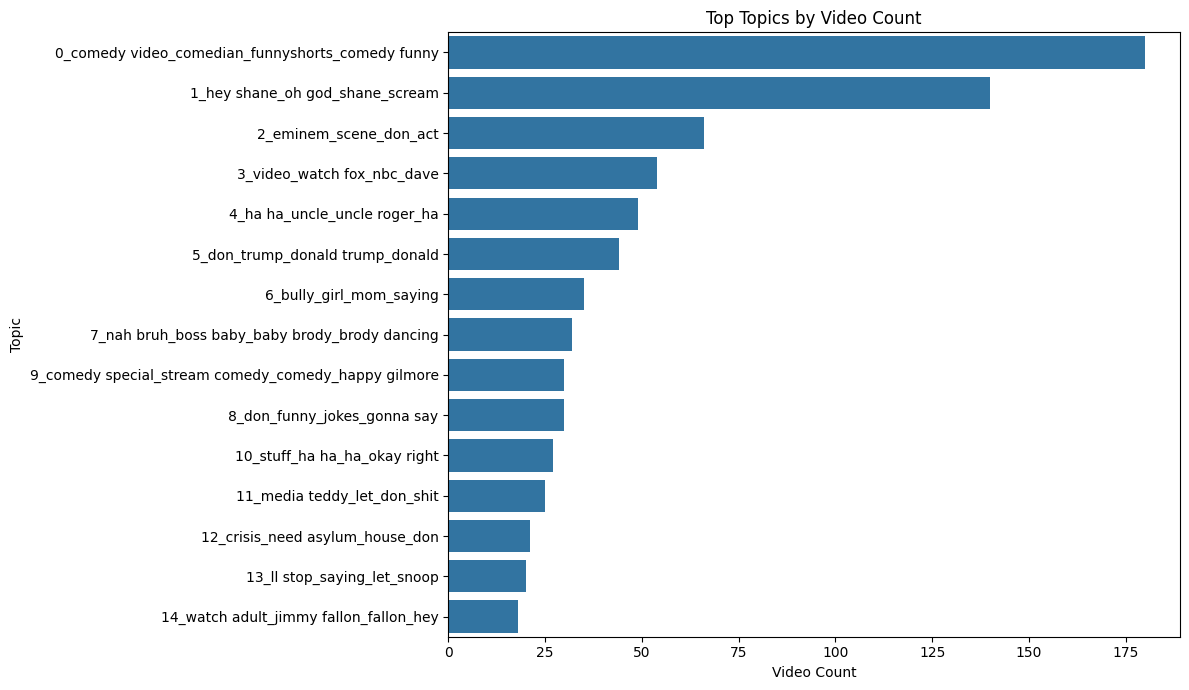

In [ ]:
plt.figure(figsize=(12,7))

sns.barplot(
    data=top_topics,
    x="Count",
    y="Name"
)

plt.title("Top Topics by Video Count")
plt.xlabel("Video Count")
plt.ylabel("Topic")

plt.tight_layout()
plt.show()

In [ ]:
df["share"] = df["Count"] / df["Count"].sum()

df = df.sort_values("share", ascending=False)

display(df[["Topic","Name","Count","share"]].head(15))

,Topic,Name,Count,share
1,0,0_comedy video_comedian_funnyshorts_comedy funny,180,0.224159
2,1,1_hey shane_oh god_shane_scream,140,0.174346
3,2,2_eminem_scene_don_act,66,0.082192
4,3,3_video_watch fox_nbc_dave,54,0.067248
5,4,4_ha ha_uncle_uncle roger_ha,49,0.061021
6,5,5_don_trump_donald trump_donald,44,0.054795
7,6,6_bully_girl_mom_saying,35,0.043587
8,7,7_nah bruh_boss baby_baby brody_brody dancing,32,0.039851
10,9,9_comedy special_stream comedy_comedy_happy gi...,30,0.037360
9,8,8_don_funny_jokes_gonna say,30,0.037360


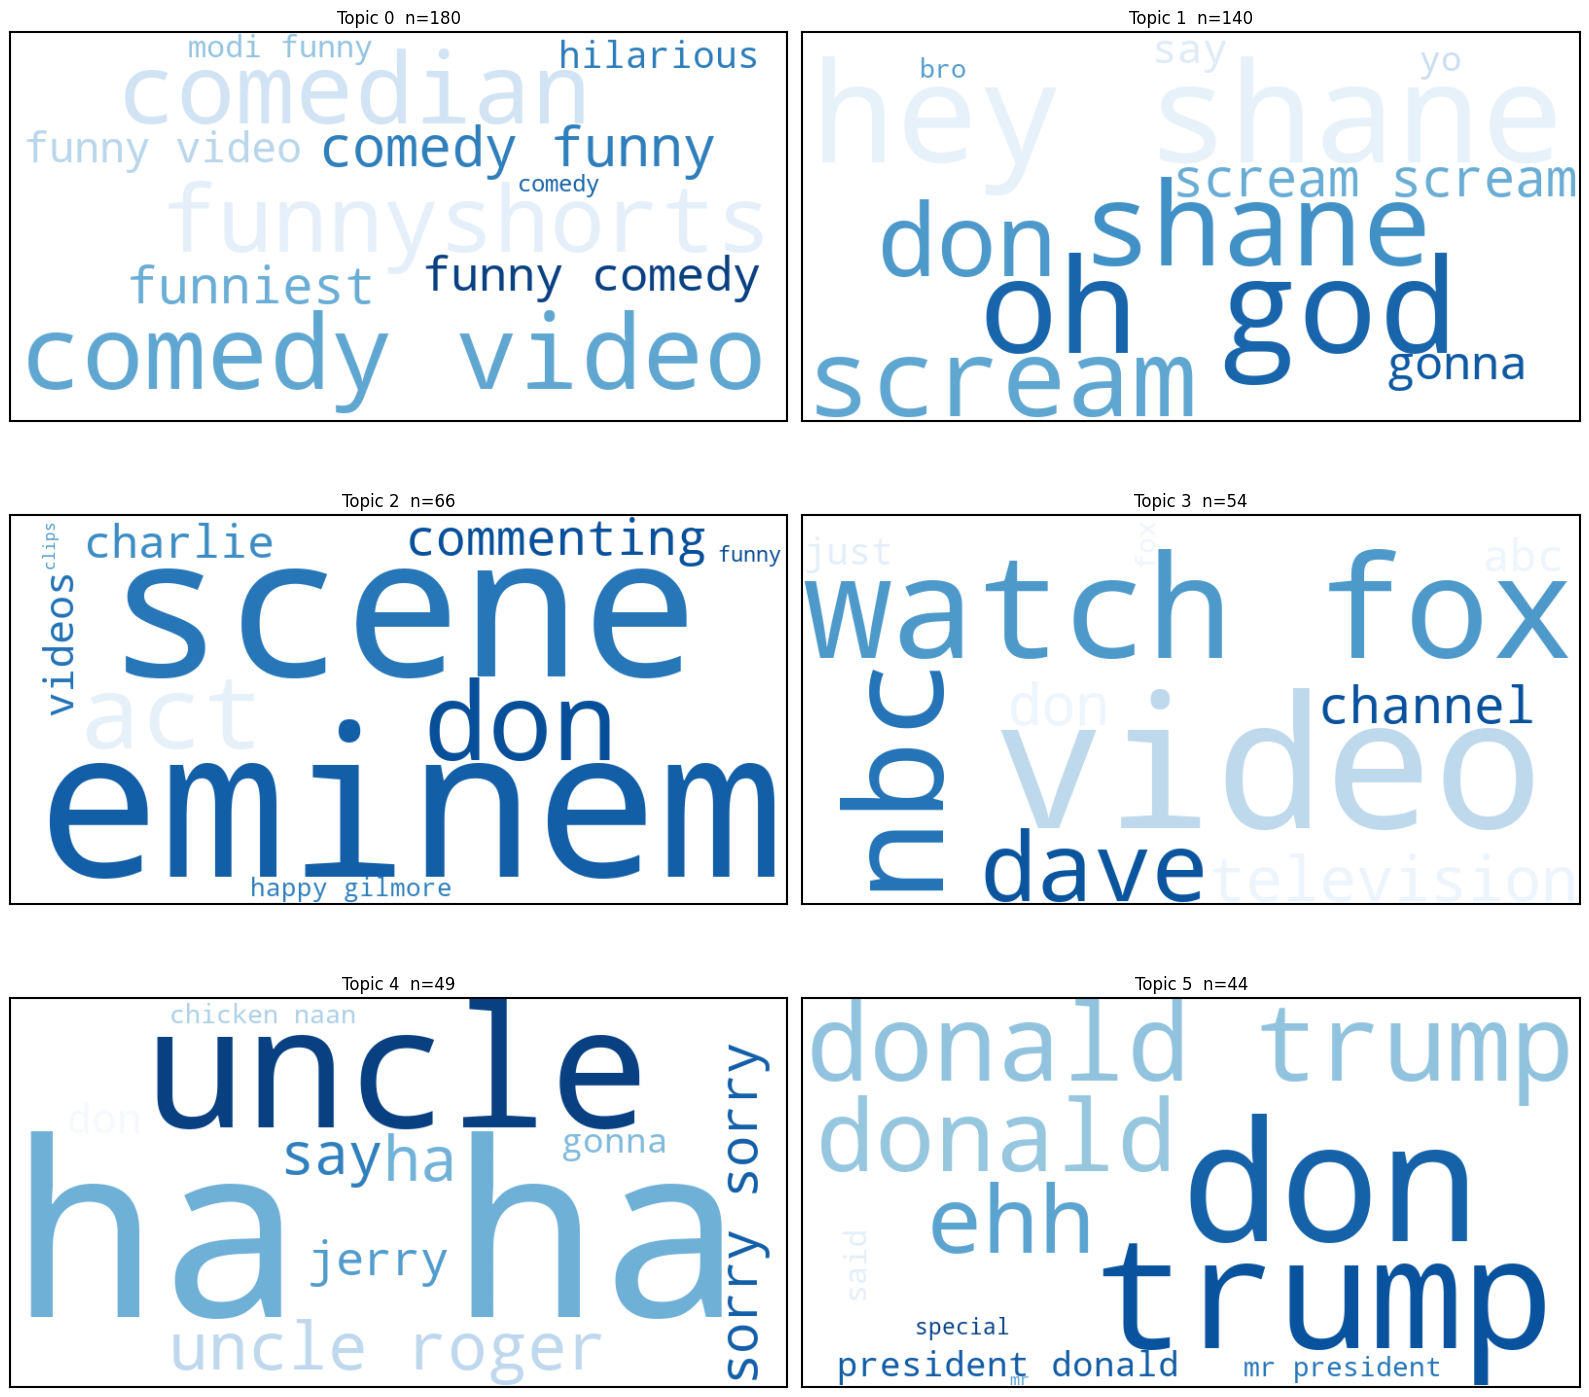

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re
import math

#TOPIC_INFO_PATH = "/home/kiwi-pandas/Documents/humor-harm-api/scripts/topic_analysis/topic_analysis_bertopic_topic_info.csv"
TOPIC_INFO_PATH = r"C:\Users\CS-Admin\Documents\humor-harm-api\scripts\topic_analysis\topic_analysis_bertopic_topic_info.csv"


topic_info = pd.read_csv(TOPIC_INFO_PATH)

# remove outlier topic
df = topic_info[topic_info["Topic"] != -1].copy()

# choose top topics by count
TOP_N = 4
plot_df = df.sort_values("Count", ascending=False).head(TOP_N).copy()

def make_freqs(rep_text):
    text = str(rep_text)
    text = re.sub(r"[\[\]'\"']", " ", text)
    words = [w.strip() for w in text.split(",") if w.strip()]
    freqs = {w: max(1, 10 - i) for i, w in enumerate(words)}
    return freqs

ncols = 2
nrows = math.ceil(len(plot_df) / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 5 * nrows))
axes = axes.flatten()

for ax, (_, row) in zip(axes, plot_df.iterrows()):
    freqs = make_freqs(row["Representation"])

    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        colormap="Blues"
    ).generate_from_frequencies(freqs)

    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"Topic {row['Topic']}  n={row['Count']}", fontsize=12)

    # remove ticks but keep border
    ax.set_xticks([])
    ax.set_yticks([])

    # show box around each subplot
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.5)

# hide unused axes
for ax in axes[len(plot_df):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Cell 1: Load and merge

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

TOPICS_PATH = "/home/kiwi-pandas/Documents/humor-harm-api/scripts/topic_analysis/topic_analysis_bertopic_topic_info.csv"
MAIN_PATH = "/home/kiwi-pandas/Documents/humor-harm-api/unified_dataset.csv"

topics_df = pd.read_csv(TOPICS_PATH)
main_df = pd.read_csv(MAIN_PATH)

merge_df = pd.merge(
    topics_df,
    main_df[["video_id", "humor_type"]],
    on="video_id",
    how="inner"
)

# keep assigned topics only
merge_df = merge_df[(merge_df["topic_id"] != -999) & (merge_df["topic_id"] != -1)].copy()

# keep only dark and regular humor
merge_df = merge_df[merge_df["humor_type"].isin(["Dark Humor", "Regular Humor"])].copy()

print(merge_df.shape)
merge_df.head()

KeyError: 'video_id'